Setup and metadata

In [2]:
import sys
sys.path.insert(0, '/code/src')

import pandas as pd 
import numpy as np
from datetime import datetime, date
import seaborn as sns
import pynwb
from matplotlib import pyplot as plt

import module
from module import get_binned_triggered_spike_counts_fast, neuron_psth
import importlib
importlib.reload(module)

from sklearn.svm import LinearSVC
from sklearn import svm
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import confusion_matrix

In [3]:
from aind_data_access_api.document_db import MetadataDbClient

API_GATEWAY_HOST = "api.allenneuraldynamics.org"
DATABASE = 'metadata_index'
COLLECTION = 'data_assets'

docdb_api_client = MetadataDbClient(
   host=API_GATEWAY_HOST,
    version="v2",
   database=DATABASE,
   collection=COLLECTION,
)
print(docdb_api_client._base_url)

https://api.allenneuraldynamics.org/v2/metadata_index/data_assets


In [4]:
aggregate = [
  {
    "$match": {
      "data_description.project_name": "Dynamic Routing", 
      "data_description.data_level": "derived", 
      "processing.data_processes": {
        "$elemMatch": {
          "process_type": "File format conversion",
          "start_date_time": {"$regex": "^2026-08-04"}
        }
      }
    }
  },
  {
    "$project": {
      "name": 1, 
      "subject_id": "$data_description.subject_id",
      "genotype": "$subject.subject_details.genotype", 
      "date_of_birth": "$subject.subject_details.date_of_birth", 
      "sex": "$subject.subject_details.sex",  
      "session_start_time": "$acquisition.acquisition_start_time",
      "session_end_time": "$acquisition.acquisition_end_time", 
      "stimulus_epochs": "$acquisition.stimulus_epochs",
      "project_name": "$data_description.project_name", 
      "modality": "$data_description.modalities.name", 
      "targeted_structure": "$acquisition.data_streams.configurations.probes.primary_targeted_structure.name" 
    }
  },
]
    
records = docdb_api_client.aggregate_docdb_records(pipeline=aggregate)

# Extract performance metrics in Python
for r in records:
    dr = next((e for e in r.get("stimulus_epochs", []) if e.get("stimulus_name") == "DynamicRouting1"), None)
    r["dr_performance"] = dr["performance_metrics"] if dr else None

In [5]:
df = pd.DataFrame(records)
df['session_date'] = df.apply(lambda x: datetime.fromisoformat(x['session_start_time']).date(), axis=1)
df['session_start_time'] = df.apply(lambda x: datetime.fromisoformat(x['session_start_time']).time(), axis=1)
df['session_end_time'] = df.apply(lambda x: datetime.fromisoformat(x['session_end_time']).time(), axis=1)
df['date_of_birth'] = df.apply(lambda x: datetime.strptime(x['date_of_birth'], '%Y-%m-%d').date(), axis=1)
df['age'] = df.apply(lambda x: (x['session_date'] - x['date_of_birth']).days, axis=1)

df['trials_total'] = df['dr_performance'].apply(lambda x: x['trials_total'] if x else None)
df['trials_rewarded'] = df['dr_performance'].apply(lambda x: x['trials_rewarded'] if x else None)
df['reward_rate'] = df['trials_rewarded'] / df['trials_total']
df['reward_consumed_mL'] = df['dr_performance'].apply(lambda x: x['reward_consumed_during_epoch'] if x else None)
df['block_metrics'] = df['dr_performance'].apply(lambda x: x['output_parameters']['block_metrics'] if x else None)
df['mean_dprime_same_modal'] = df['block_metrics'].apply(
    lambda x: pd.Series([b['dprime_same_modal'] for b in x.values()]).mean() if x else None
)
df['mean_dprime_other_modal'] = df['block_metrics'].apply(
    lambda x: pd.Series([b['dprime_other_modal_go'] for b in x.values()]).mean() if x else None
)

order = ['project_name', '_id', 'name', 'subject_id', 'genotype', 'date_of_birth', 'age', 'sex',
         'modality', 'session_date', 'session_start_time', 'session_end_time', 'targeted_structure',
         'trials_total', 'trials_rewarded', 'reward_rate', 'reward_consumed_mL',
         'mean_dprime_same_modal', 'mean_dprime_other_modal']
df = df[order].sort_values(by='subject_id')
df

,project_name,_id,name,subject_id,genotype,date_of_birth,age,sex,modality,session_date,session_start_time,session_end_time,targeted_structure,trials_total,trials_rewarded,reward_rate,reward_consumed_mL,mean_dprime_same_modal,mean_dprime_other_modal
2,Dynamic Routing,66dc0f20-45dc-4a65-ac3a-0a04ac0e1df4,ecephys_662892_2023-08-24_14-28-28_nwb_2026-08...,662892,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2022-12-24,243,Female,"[Extracellular electrophysiology, Behavior, Be...",2023-08-24,14:28:28,16:28:14.588745,"[[[Piriform area], [root]]]",476,123,0.258403,3.8400000000000016,2.152875,2.209537
6,Dynamic Routing,0f42545e-0e5f-4dfc-9777-8070c1e69ffd,ecephys_664851_2023-11-16_12-54-53_nwb_2026-08...,664851,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2023-01-09,311,Female,"[Extracellular electrophysiology, Behavior, Be...",2023-11-16,12:54:53,14:46:25.481437,"[[[Secondary motor area], [Field CA1], [Subicu...",527,139,0.263757,4.35,3.133879,2.593231
3,Dynamic Routing,468a63e1-6e2f-494e-8448-f8bf07afcad5,ecephys_667252_2023-09-28_15-00-38_nwb_2026-08...,667252,wt/wt,2023-01-27,244,Female,"[Extracellular electrophysiology, Behavior, Be...",2023-09-28,15:00:38,17:03:03.333877,"[[[Secondary motor area], [Primary motor area]...",486,123,0.253086,3.7800000000000002,3.261005,2.260717
10,Dynamic Routing,b0377871-8621-45b2-8c31-a3957d669787,ecephys_708016_2024-04-29_12-59-12_nwb_2026-08...,708016,Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2023-10-18,194,Male,"[Extracellular electrophysiology, Behavior, Be...",2024-04-29,12:59:12,15:00:31.755703,"[[[Secondary motor area], [Primary somatosenso...",533,129,0.242026,4.049999999999999,3.027970,2.665116
11,Dynamic Routing,ada82eb8-3f9c-4c80-9dbe-30b25114a391,ecephys_712815_2024-05-22_12-26-32_nwb_2026-08...,712815,wt/wt,2023-11-17,187,Female,"[Extracellular electrophysiology, Behavior, Be...",2024-05-22,12:26:32,14:23:25.111009,"[[[Dentate gyrus], [Posterior complex of the t...",545,138,0.253211,4.17,2.988601,1.745163
4,Dynamic Routing,1055573d-b0f0-4b31-a648-131ccddff1c8,ecephys_713655_2024-08-09_10-41-47_nwb_2026-08...,713655,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2023-11-23,260,Male,"[Extracellular electrophysiology, Behavior, Be...",2024-08-09,10:41:47,12:49:52.580059,"[[[Anterodorsal nucleus], [Supplemental somato...",515,129,0.250485,4.02,2.841083,3.002527
8,Dynamic Routing,6baeab62-02b8-4de7-8ca4-2ab5da7e0f20,ecephys_714748_2024-06-24_12-52-23_nwb_2026-08...,714748,Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2023-12-01,206,Male,"[Extracellular electrophysiology, Behavior, Be...",2024-06-24,12:52:23,14:59:27.907510,"[[[Supplemental somatosensory area], [Secondar...",550,134,0.243636,4.229999999999999,3.329563,2.693473
9,Dynamic Routing,5a958ba6-ebe7-400a-8021-3230170e6638,ecephys_715710_2024-07-16_12-58-34_nwb_2026-08...,715710,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2023-12-07,222,Male,"[Extracellular electrophysiology, Behavior, Be...",2024-07-16,12:58:34,15:05:31.280219,"[[[Supplemental somatosensory area], [Midbrain...",548,131,0.239051,4.049999999999999,2.032598,1.928238
7,Dynamic Routing,6774fb39-4c19-4ba2-99f5-2609fb1b9d77,ecephys_741137_2024-10-10_13-15-50_nwb_2026-08...,741137,wt/wt,2024-03-19,205,Male,"[Extracellular electrophysiology, Behavior, Be...",2024-10-10,13:15:50,15:19:11.275413,"[[[Retrosplenial area, dorsal part], [Suppleme...",543,124,0.228361,5.2,3.113432,2.623589
0,Dynamic Routing,c5bc8e0e-81ee-4e52-a7b6-90089b0dfc5f,ecephys_742903_2024-10-23_14-12-23_nwb_2026-08...,742903,Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2024-05-16,160,Female,"[Extracellular electrophysiology, Behavior, Be...",2024-10-23,14:12:23,16:15:54.652646,"[[[Primary somatosensory area], [Caudoputamen]...",489,124,0.253579,5.2,3.177007,2.342171


In [6]:
print(f'number of mice: {len(df)}')

number of mice: 12


Dynamic routing data

In [7]:
nwb_path = "/data/dynamicrouting_datacube/ecephys_759434_2025-02-04_12-27-22_nwb_2026-08-04_15-01-21/759434_2025-02-04.nwb.zarr"
nwbfile = pynwb.read_nwb(nwb_path)
nwbfile

/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (420648, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (420666, 500) float32 read-only>
  warnings.warn(


,timestamps
id,
0,NaN
1,14.42651
2,14.44318
3,14.45984
,timestamps
id,
0,NaN
1,14.64815
2,14.66481


In [8]:
all_units = nwbfile.units[:]
all_units

,activity_drift,amplitude,amplitude_cutoff,amplitude_cv_median,amplitude_cv_range,amplitude_median,ccf_ap,ccf_dv,ccf_ml,cluster_id,...,structure,sync_spike_2,sync_spike_4,sync_spike_8,unit_id,velocity_above,velocity_below,spike_times,obs_intervals,electrode_group
id,,,,,,,,,,,,,,,,,,,,,
0,0.310182,86.687622,0.002210,0.292047,0.291903,67.860000,4625.0,5100.0,2900.0,0,...,CP,0.034051,0.000097,0.0,759434_2025-02-04_B-0,301.814836,NaN,"[20.899214575483686, 21.360979519709296, 22.05...","[[20.24118369668792, 7025.1210546177235]]",probeB pynwb.ecephys.ElectrodeGroup at 0x13986...
1,0.175051,251.456230,0.000043,NaN,NaN,124.020000,4625.0,5100.0,2900.0,1,...,CP,0.040819,0.000000,0.0,759434_2025-02-04_B-1,NaN,NaN,"[20.57621578030963, 20.593715715032687, 20.804...","[[20.24118369668792, 7025.1210546177235]]",probeB pynwb.ecephys.ElectrodeGroup at 0x13986...
2,0.054430,98.420357,0.000126,0.274439,0.277458,72.540000,4675.0,5050.0,2900.0,2,...,CP,0.038799,0.000000,0.0,759434_2025-02-04_B-2,NaN,NaN,"[20.31891674006727, 20.34118332367679, 20.5163...","[[20.24118369668792, 7025.1210546177235]]",probeB pynwb.ecephys.ElectrodeGroup at 0x13986...
3,0.053826,65.543402,0.000125,NaN,NaN,30.419998,4625.0,5075.0,2900.0,3,...,CP,0.175586,0.000596,0.0,759434_2025-02-04_B-3,NaN,NaN,"[33.335501519909634, 33.34220149491789, 33.343...","[[20.24118369668792, 7025.1210546177235]]",probeB pynwb.ecephys.ElectrodeGroup at 0x13986...
4,0.086663,59.702768,0.000152,NaN,NaN,28.079998,4625.0,5100.0,2900.0,4,...,CP,0.088795,0.000370,0.0,759434_2025-02-04_B-4,NaN,NaN,"[23.240672508219102, 23.24733915001836, 23.250...","[[20.24118369668792, 7025.1210546177235]]",probeB pynwb.ecephys.ElectrodeGroup at 0x13986...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2280,0.131299,409.724686,0.002443,0.097417,0.392093,276.120000,3150.0,2150.0,4550.0,267,...,MOs,0.021467,0.000000,0.0,759434_2025-02-04_F-267,605.804791,NaN,"[25.087532998134833, 45.13632054470185, 46.167...","[[20.24268545106928, 7025.104241617593]]",probeF pynwb.ecephys.ElectrodeGroup at 0x13986...
2281,0.369669,268.837971,0.000061,NaN,NaN,208.260000,3050.0,1925.0,4450.0,268,...,MOs,0.019299,0.000000,0.0,759434_2025-02-04_F-268,601.837297,NaN,"[871.2026272412407, 1988.115019482439, 2331.90...","[[20.24268545106928, 7025.104241617593]]",probeF pynwb.ecephys.ElectrodeGroup at 0x13986...
2282,0.230310,176.375221,0.000160,NaN,NaN,145.080000,3050.0,1925.0,4500.0,269,...,MOs,0.030272,0.000000,0.0,759434_2025-02-04_F-269,396.446107,NaN,"[192.23354004343028, 206.68124969396942, 232.1...","[[20.24268545106928, 7025.104241617593]]",probeF pynwb.ecephys.ElectrodeGroup at 0x13986...


In [9]:
# Combine and count the structure and default_qc columns to identify the number of good units in each brain structure. 

all_units.groupby("structure")["default_qc"].agg(passing="sum", total="count").sort_values("passing", ascending=False)

,passing,total
structure,,
SSp,87,460
MOs,70,598
CP,66,442
TTd,42,87
ILA,32,153
DP,32,117
CA3,25,192
PL,22,108
CA1,8,47


In [10]:
units_table = nwbfile.units.to_dataframe()

Quality control

In [11]:
# QC thresholds
MAX_ISI_VIOLATIONS_RATIO = 0.5    # lower is better
MAX_AMPLITUDE_CUTOFF = 0.1        # lower is better
MIN_PRESENCE_RATIO = 0.95         # higher is better

good_units1 = units_table[
    (units_table.isi_violations_ratio < MAX_ISI_VIOLATIONS_RATIO) &
    (units_table.amplitude_cutoff < MAX_AMPLITUDE_CUTOFF) &
    (units_table.presence_ratio > MIN_PRESENCE_RATIO)
]
print('%d of %d units passed thresholded quality control' % (len(good_units1), len(units_table)))

# Default QC
good_units2 = units_table[
    (units_table.default_qc)
]

print('%d of %d units passed default quality control' % (len(good_units2), len(units_table)))

968 of 2285 units passed thresholded quality control
394 of 2285 units passed default quality control


In [12]:
# Find overlapping indices for two QC methods
shared_indices = good_units1.index.intersection(good_units2.index)

# Filter to get the overlapping rows
qc_units = units_table.loc[shared_indices]

print(f'{len(qc_units)} units overlap between both groups')
qc_units

338 units overlap between both groups


,activity_drift,amplitude,amplitude_cutoff,amplitude_cv_median,amplitude_cv_range,amplitude_median,ccf_ap,ccf_dv,ccf_ml,cluster_id,...,structure,sync_spike_2,sync_spike_4,sync_spike_8,unit_id,velocity_above,velocity_below,spike_times,obs_intervals,electrode_group
id,,,,,,,,,,,,,,,,,,,,,
2,0.054430,98.420357,0.000126,0.274439,0.277458,72.540000,4675.0,5050.0,2900.0,2,...,CP,0.038799,0.00000,0.0,759434_2025-02-04_B-2,NaN,NaN,"[20.31891674006727, 20.34118332367679, 20.5163...","[[20.24118369668792, 7025.1210546177235]]",probeB pynwb.ecephys.ElectrodeGroup at 0x13986...
15,0.022644,234.622452,0.000236,NaN,NaN,133.379990,4675.0,4950.0,2900.0,15,...,CP,0.046404,0.00000,0.0,759434_2025-02-04_B-15,NaN,265.709371,"[20.299716811685403, 20.383649831938065, 20.38...","[[20.24118369668792, 7025.1210546177235]]",probeB pynwb.ecephys.ElectrodeGroup at 0x13986...
23,0.053354,213.815186,0.001013,NaN,NaN,170.819990,4650.0,4825.0,2925.0,24,...,CP,0.042693,0.00000,0.0,759434_2025-02-04_B-24,NaN,138.775506,"[21.646011789836574, 22.187943101698263, 22.96...","[[20.24118369668792, 7025.1210546177235]]",probeB pynwb.ecephys.ElectrodeGroup at 0x13986...
26,0.015610,173.309776,0.000736,0.166979,0.443848,121.679990,4650.0,4750.0,2925.0,27,...,CP,0.060175,0.00026,0.0,759434_2025-02-04_B-27,NaN,312.668313,"[20.28038355046756, 20.592715718762797, 20.658...","[[20.24118369668792, 7025.1210546177235]]",probeB pynwb.ecephys.ElectrodeGroup at 0x13986...
31,0.077786,114.051579,0.000062,NaN,NaN,88.920000,4650.0,4650.0,2950.0,32,...,CP,0.034645,0.00000,0.0,759434_2025-02-04_B-32,NaN,NaN,"[21.56921207630912, 21.57434539049455, 21.5787...","[[20.24118369668792, 7025.1210546177235]]",probeB pynwb.ecephys.ElectrodeGroup at 0x13986...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2237,0.074782,125.461462,0.000499,0.207668,0.132549,93.600000,3000.0,1750.0,4400.0,224,...,MOs,0.025174,0.00000,0.0,759434_2025-02-04_F-224,243.105821,-858.818859,"[31.933172649317893, 69.98605581157975, 74.813...","[[20.24268545106928, 7025.104241617593]]",probeF pynwb.ecephys.ElectrodeGroup at 0x13986...
2246,0.099902,141.687057,0.000081,0.154486,0.079503,109.979996,3950.0,4700.0,5725.0,233,...,OLF,0.024683,0.00000,0.0,759434_2025-02-04_F-233,NaN,NaN,"[31.258875310350263, 31.71537350883569, 34.369...","[[20.24268545106928, 7025.104241617593]]",probeF pynwb.ecephys.ElectrodeGroup at 0x13986...
2251,0.059138,104.083183,0.000370,0.253331,0.148398,70.200000,3550.0,3500.0,5200.0,238,...,ILA,0.025952,0.00000,0.0,759434_2025-02-04_F-238,NaN,263.798351,"[23.97967070351186, 27.56215656566748, 28.9132...","[[20.24268545106928, 7025.104241617593]]",probeF pynwb.ecephys.ElectrodeGroup at 0x13986...


50 good units in CP


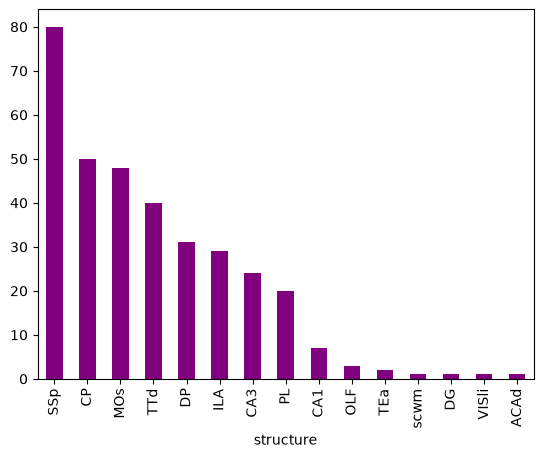

In [13]:
qc_units.structure.value_counts().plot.bar(color='purple')

select_region = 'CP'
region_units = qc_units[qc_units.structure == select_region]
print(f'{len(region_units)} good units in {select_region}')

Plot example units

In [14]:
trials = nwbfile.trials.to_dataframe()
trials.head()

,start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,...,is_vis_target,is_nontarget,is_aud_nontarget,is_vis_nontarget,is_vis_rewarded,is_aud_rewarded,is_block_switch,is_repeat,is_opto,is_task_control_correct
id,,,,,,,,,,,,,,,,,,,,,
0,2158.88748,2164.39167,2158.88748,2160.35497,2160.415740,2160.916160,2160.47170,2161.38916,2161.07221,2161.06612,...,True,False,False,False,True,False,False,False,False,False
1,2165.30909,2170.81367,2165.30909,2166.77695,2166.837800,2167.338220,2166.89376,2167.81124,2167.22735,2167.21475,...,True,False,False,False,True,False,False,False,False,False
2,2172.76534,2178.28664,2172.76534,2174.23327,2174.294050,2174.794460,2174.34997,2175.26747,2174.60025,2174.59576,...,True,False,False,False,True,False,False,False,False,False
3,2179.65444,2185.17571,2179.65444,2181.12234,2181.183375,2181.683795,2181.23910,2182.15653,2181.47267,2181.46901,...,True,False,False,False,True,False,False,False,False,False
4,2185.29248,2190.81381,2185.29248,2186.76041,2186.821210,2187.321630,2186.87719,2187.79464,2187.09402,2187.09076,...,True,False,False,False,True,False,False,False,False,False


In [19]:
# vis1 and aud1 onsets, visual context only (context fixed)
vis1_stim_time_array = trials.loc[
    (trials.stim_name == 'vis1') & (trials.rewarded_modality == 'vis'),
    'stim_start_time'].values
aud1_stim_time_array = trials.loc[
    (trials.stim_name == 'sound1') & (trials.rewarded_modality == 'vis'), # stim aud 1 under visual block
    'stim_start_time'].values
print('visual-context trials: vis1 = %d, sound1 = %d'
      % (len(vis1_stim_time_array), len(aud1_stim_time_array)))

visual-context trials: vis1 = 74, sound1 = 59


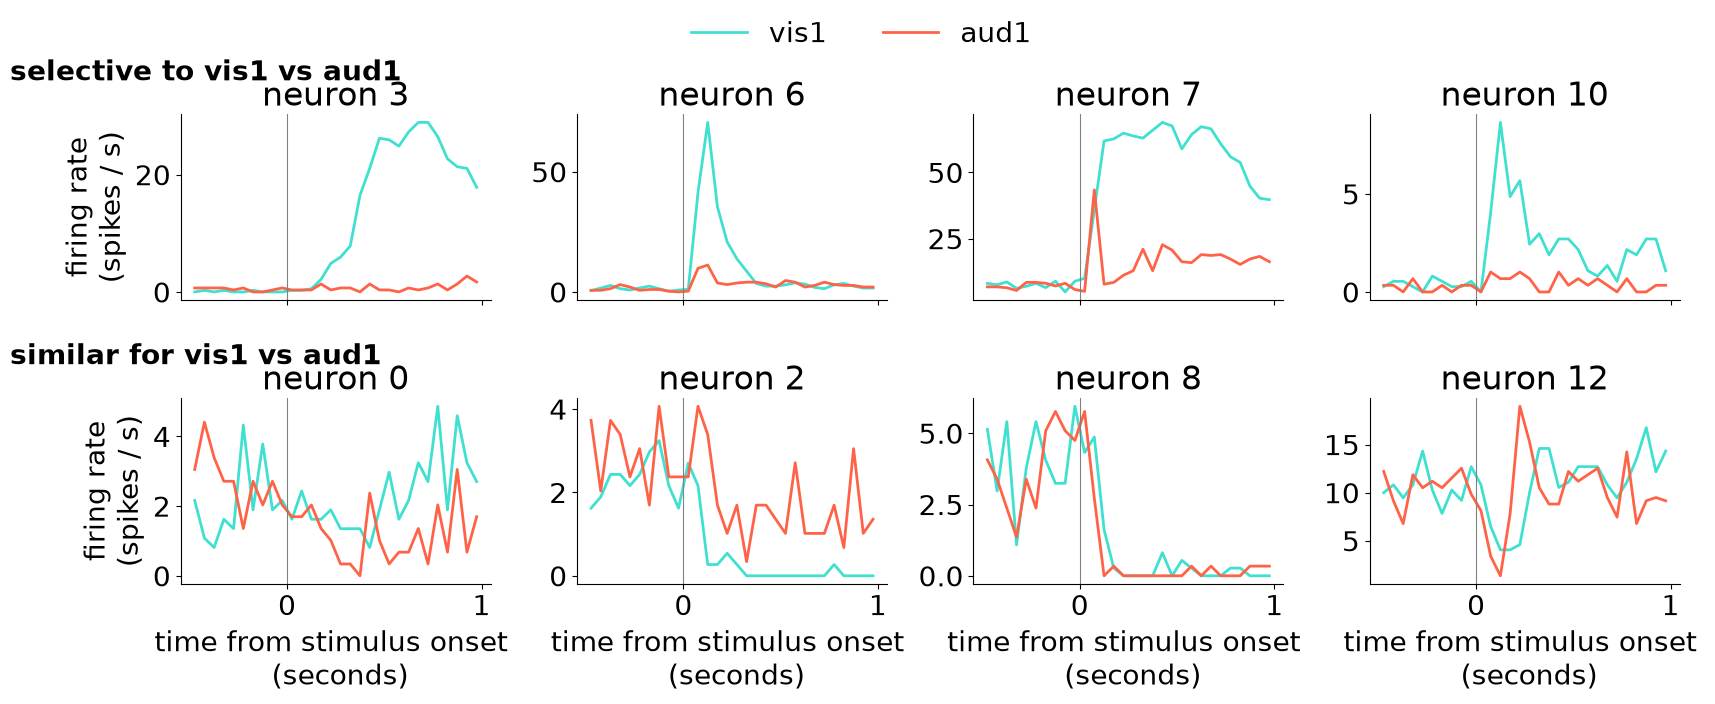

In [28]:
selective_units = [3, 6, 7, 10]
similar_units = [0, 2, 8, 12]

color1 = 'turquoise'
color2 = 'tomato'

# PSTH time bins, -0.5 to 1.0 s around onset, 50 ms wide
psth_bin_edge_array = np.arange(-0.5, 1.0 + 0.05, 0.05)
psth_bin_center_array = psth_bin_edge_array[:-1] + 0.05 / 2

plt.rcParams.update({'font.size': 20}) 
fig, ax = plt.subplots(2, 4, figsize=(17, 7), sharex=True)
row_index_list = [selective_units, similar_units]
row_text_list = ['selective to vis1 vs aud1', 'similar for vis1 vs aud1']
for row in range(2):
    for col in range(4):
        neuron_row_index = row_index_list[row][col]
        single_ax = ax[row, col]
        single_ax.plot(psth_bin_center_array,
                       neuron_psth(region_units, neuron_row_index, vis1_stim_time_array, psth_bin_edge_array),
                       color=color1, linewidth=2, label='vis1')
        single_ax.plot(psth_bin_center_array,
                       neuron_psth(region_units, neuron_row_index, aud1_stim_time_array, psth_bin_edge_array),
                       color=color2, linewidth=2, label='aud1')
        single_ax.axvline(0, color='0.5', linewidth=0.8)
        single_ax.set_title('neuron %d' % neuron_row_index)
        sns.despine(ax=single_ax)
    ax[row, 0].set_ylabel('firing rate\n(spikes / s)')
    ax[row, 0].annotate(row_text_list[row], xy=(-0.55, 1.18),
                        xycoords='axes fraction', fontweight='bold')
for single_ax in ax[-1, :]:
    single_ax.set_xlabel('time from stimulus onset \n (seconds)')
handle_list, label_list = ax[0, 0].get_legend_handles_labels()
fig.legend(handle_list, label_list, title='',
           loc='upper center', bbox_to_anchor=(0.5, 1.04), ncol=2, frameon=False)
fig.subplots_adjust(hspace=0.5, wspace=0.4)
fig.tight_layout()
plt.show()

Session epochs

In [1]:
epochs = nwbfile.intervals["epochs"].to_dataframe()
epochs.head()

NameError: name 'nwbfile' is not defined

Behavior

In [21]:
performance = nwbfile.intervals["performance"].to_dataframe()
performance.head()

,start_time,stop_time,block_index,n_trials,n_responses,n_hits,n_contingent_rewards,hit_rate,false_alarm_rate,catch_response_rate,rewarded_modality,is_first_block_aud,cross_modality_dprime,signed_cross_modality_dprime,vis_dprime,aud_dprime,vis_target_response_rate,vis_nontarget_response_rate,aud_target_response_rate,aud_nontarget_response_rate
id,,,,,,,,,,,,,,,,,,,,
0,2158.88748,2763.96067,0,92,25.0,24.0,24.0,1.000000,0.016667,3.125000,vis,False,3.681688,3.681688,3.996798,0.000000,1.000000,0.00,0.05,0.000000
1,2764.91140,3369.10091,1,89,38.0,21.0,21.0,0.954545,0.280702,3.800000,aud,False,1.889823,-1.889823,0.000000,1.889823,0.421053,0.00,1.00,0.421053
2,3369.86822,3976.22623,2,89,26.0,24.0,24.0,0.960000,0.035088,3.714286,vis,False,3.688618,3.688618,3.395540,-0.344713,1.000000,0.05,0.00,0.055556
3,3976.52642,4584.60250,3,89,36.0,23.0,23.0,1.000000,0.228070,4.000000,aud,False,2.498592,-2.498592,-0.293078,2.449813,0.315789,0.05,1.00,0.333333
4,4584.90278,5191.94456,4,93,27.0,25.0,25.0,1.000000,0.032787,3.857143,vis,False,3.698603,3.698603,4.034501,-0.315110,1.000000,0.00,0.05,0.050000


In [22]:
nwbfile.processing['behavior']

Name,/processing/behavior/facemap_front_camera/data
Type,zarr.core.Array
Data type,float32
Shape,"(420648, 500)"
Chunk shape,"(13146, 32)"
Order,C
Read-only,True
Compressor,"Blosc(cname='lz4', clevel=5, shuffle=SHUFFLE, blocksize=0)"
Store type,zarr.storage.ConsolidatedMetadataStore
Chunk store type,zarr.storage.DirectoryStore
No. bytes,841296000 (802.3M)


In [23]:
running = nwbfile.processing['behavior']['running_speed'].data[:]
running_timestamps = nwbfile.processing['behavior']['running_speed'].timestamps[:]

In [24]:
eye_tracking = nwbfile.processing['behavior']['eye_tracking'][0:10] # large table, so just getting the first 10 rows 
eye_tracking

,cr_center_x,cr_center_y,cr_width,cr_height,cr_phi,cr_average_confidence,cr_area,cr_is_bad_frame,eye_center_x,eye_center_y,...,eye_is_bad_frame,pupil_center_x,pupil_center_y,pupil_width,pupil_height,pupil_phi,pupil_average_confidence,pupil_area,pupil_is_bad_frame,timestamps
id,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,0.006526,NaN,True,NaN,NaN,...,True,NaN,NaN,NaN,NaN,NaN,0.007274,NaN,True,NaN
1,NaN,NaN,NaN,NaN,NaN,0.040957,NaN,True,292.777818,257.166495,...,False,NaN,NaN,NaN,NaN,NaN,0.001929,NaN,True,14.42651
2,NaN,NaN,NaN,NaN,NaN,0.062446,NaN,True,298.465554,259.710655,...,False,NaN,NaN,NaN,NaN,NaN,0.002546,NaN,True,14.44318
3,NaN,NaN,NaN,NaN,NaN,0.115949,NaN,True,301.227109,262.851161,...,False,NaN,NaN,NaN,NaN,NaN,0.003615,NaN,True,14.45984
4,NaN,NaN,NaN,NaN,NaN,0.118731,NaN,True,298.783399,261.915275,...,False,NaN,NaN,NaN,NaN,NaN,0.004573,NaN,True,14.47651
5,NaN,NaN,NaN,NaN,NaN,0.103269,NaN,True,299.359589,262.008616,...,False,NaN,NaN,NaN,NaN,NaN,0.004557,NaN,True,14.49317
6,NaN,NaN,NaN,NaN,NaN,0.110515,NaN,True,300.013752,260.932320,...,False,NaN,NaN,NaN,NaN,NaN,0.004408,NaN,True,14.50984
7,NaN,NaN,NaN,NaN,NaN,0.108935,NaN,True,302.067252,259.293426,...,False,NaN,NaN,NaN,NaN,NaN,0.005164,NaN,True,14.52651
8,NaN,NaN,NaN,NaN,NaN,0.139220,NaN,True,303.438215,258.568456,...,False,NaN,NaN,NaN,NaN,NaN,0.005924,NaN,True,14.54317


In [25]:
front_camera = nwbfile.processing['behavior']['lp_front_camera'][0:10] # taking a small slice of the table to display 
front_camera

,ear_base_l_likelihood,ear_base_l_pca_error,ear_base_l_temporal_norm,ear_base_l_x,ear_base_l_y,ear_tip_l_likelihood,ear_tip_l_pca_error,ear_tip_l_temporal_norm,ear_tip_l_x,ear_tip_l_y,...,whisker_pad_l_side_pca_error,whisker_pad_l_side_temporal_norm,whisker_pad_l_side_x,whisker_pad_l_side_y,whisker_pad_l_top_likelihood,whisker_pad_l_top_pca_error,whisker_pad_l_top_temporal_norm,whisker_pad_l_top_x,whisker_pad_l_top_y,timestamps
id,,,,,,,,,,,,,,,,,,,,,
0,0.000136,109.305099,NaN,314.509033,214.964294,0.000172,112.505379,NaN,327.771851,236.113205,...,113.855881,NaN,332.498230,243.779175,0.000153,94.381584,NaN,326.739655,240.801239,NaN
1,0.988053,108.866219,112.602974,419.982544,175.533737,0.972307,107.616699,152.396545,450.785309,146.155457,...,107.937508,18.800714,316.760559,233.493622,0.999953,76.962456,27.115084,308.014008,221.190582,14.64815
2,0.994776,108.198898,1.337913,419.241333,176.647568,0.951950,106.964584,1.372030,451.922363,146.923294,...,108.049652,1.690798,315.190399,234.120834,0.998654,77.097771,0.746137,307.282532,221.043396,14.66481
3,0.981099,109.902542,2.212809,421.370148,176.043686,0.971989,108.579208,2.934833,452.630219,144.075104,...,108.192528,1.805767,316.885529,233.498474,0.998660,76.209915,0.386780,307.018433,220.760818,14.68148
4,0.985794,108.618919,0.730171,422.070435,175.836929,0.964218,107.511787,2.359758,451.809570,146.287567,...,107.920067,0.554303,317.141602,233.006866,0.999568,76.376831,0.614517,307.605255,220.578415,14.69815
5,0.994461,109.095413,1.611695,421.305511,177.255539,0.979128,107.779579,0.223019,451.841522,146.066849,...,107.791252,0.934144,317.630280,232.210739,0.998033,76.076538,0.763619,307.503021,219.821671,14.71481
6,0.995578,107.994415,0.938925,421.914246,176.540680,0.981624,106.795395,2.411428,452.020599,148.471619,...,107.529922,1.920599,315.954437,233.148956,0.999416,75.978951,0.950534,306.901947,220.558029,14.73148
7,0.990939,108.525406,0.579094,421.958405,175.963272,0.930161,107.448532,1.789298,451.991547,146.682556,...,108.544914,1.044766,316.659058,233.920349,0.997225,76.289452,0.601790,307.502472,220.519028,14.74814
8,0.991479,109.543335,0.940580,421.020203,176.030121,0.996581,108.356750,1.151731,451.708801,145.566071,...,107.930389,0.816996,316.345490,233.165924,0.997671,76.209831,0.031022,307.477783,220.500244,14.76481


In [26]:
side_camera = nwbfile.processing['behavior']['lp_side_camera'][0:10] 
side_camera

,ear_base_l_likelihood,ear_base_l_pca_error,ear_base_l_temporal_norm,ear_base_l_x,ear_base_l_y,ear_tip_l_likelihood,ear_tip_l_pca_error,ear_tip_l_temporal_norm,ear_tip_l_x,ear_tip_l_y,...,whisker_pad_l_side_pca_error,whisker_pad_l_side_temporal_norm,whisker_pad_l_side_x,whisker_pad_l_side_y,whisker_pad_l_top_likelihood,whisker_pad_l_top_pca_error,whisker_pad_l_top_temporal_norm,whisker_pad_l_top_x,whisker_pad_l_top_y,timestamps
id,,,,,,,,,,,,,,,,,,,,,
0,0.000168,113.267677,NaN,333.837036,246.252258,0.000165,79.879768,NaN,320.156891,243.217575,...,109.493004,NaN,648.755249,153.953262,0.000008,184.805695,NaN,633.057129,423.356537,NaN
1,0.998660,19.148771,140.131393,220.169662,164.297791,0.967683,6.152155,137.327957,225.122482,144.084183,...,44.217010,493.850677,155.161819,169.890945,0.999715,13.460671,547.459656,151.391129,163.145294,14.19090
2,0.998240,16.902878,1.914873,218.254791,164.295212,0.939089,6.250778,0.101881,225.024612,144.055878,...,40.651848,0.202028,155.162720,170.092972,0.999431,11.975651,0.162747,151.438599,163.300964,14.20756
3,0.999538,19.867174,1.068522,217.237686,163.967743,0.991282,10.473170,1.310066,224.011932,143.224762,...,52.588783,0.259248,155.409256,170.173157,0.999686,13.902470,0.186598,151.563370,163.439713,14.22423
4,0.998157,21.190111,1.483017,215.807373,163.575897,0.952091,12.157774,0.727006,223.289917,143.309799,...,57.275726,0.218125,155.205444,170.250870,0.999691,14.799457,0.063464,151.555130,163.502640,14.24090
5,0.999577,19.893827,1.885730,217.609879,164.129929,0.980309,9.985878,2.482976,225.417419,144.589996,...,51.174419,0.151833,155.098679,170.142914,0.999492,13.837907,0.252490,151.411942,163.294678,14.25756
6,0.999483,19.266750,1.241381,218.796051,164.496017,0.998370,9.069194,2.284853,227.347473,145.812881,...,48.310459,0.053690,155.045715,170.151718,0.999466,13.444413,0.127135,151.284836,163.297424,14.27423
7,0.999960,21.868147,0.749405,218.600418,163.772598,0.986393,13.328960,0.948349,227.028671,144.919724,...,58.970863,0.272365,155.233627,170.348877,0.999840,15.359644,0.248939,151.437332,163.494186,14.29090
8,0.998795,20.873512,0.380976,218.239441,163.650787,0.986750,11.333743,2.604463,224.735260,143.685425,...,54.916252,0.313007,154.953735,170.208755,0.999938,14.560589,0.178571,151.299255,163.380951,14.30756
